In [67]:
import numpy as np
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import colors
import json
import pandas as pd

In [2]:
# def plot_prior_and_data(samples, ax_ad, ax_data_1, ax_data_2, data, data_i, data_name, output_dir, c14_label, data_label, fig):

#     # Computing histograms of all samples for plotting
#     chain = 4
#     X = samples[chain].T
#     D, N = X.shape

#     age = np.vstack([
#         np.ones((1, N)) * data["th"],
#         data["th"] - data["dc"] * np.cumsum(X, axis=0)
#     ])

#     # Time bins
#     dt = 1 if np.max(data["d18ort"]) - np.min(data["d18ort"]) < 2000 else 10
#     t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
#     t = t_edges[1:] - dt / 2
#     T = t.size

#     # Depth interpolation grid
#     dz = data["H"] / 1000
#     z = np.arange(0, data["dc"] * D + dz, dz)
#     Z = z.size

#     # Allocate result
#     C = np.full((Z, T), np.nan)
#     A = np.array([
#         np.interp(z, data["cs"], age[:, j])
#         for j in range(N)
#     ]).T

#     for j in range(Z):
#         C[j, :], _ = np.histogram(A[j, :], bins=t_edges, density = True)

#     C /= (np.sum(C, axis=1, keepdims=True) + 1e-12)
#     C[C<=0] = np.nan

#     # Prior mean and std for plotting
#     prior_mean = data["th"] - np.array(data["cs"]) * np.exp(data["pm"] + (data["ps"]**2 / 2))
#     prior_2_std = 2 * np.sqrt(np.array(data["cs"]) * data["dc"] * (np.exp(data["ps"]**2)-1) * np.exp(2*data["pm"] + data["ps"]**2))

#     model_ages_list = []
#     cutout = 1000
#     samples = samples[:, cutout:, :]

#     sample = np.load(f"{output_dir}/{data_name}/{data_i}/true_sample.npy")
#     data_file = pd.read_csv(
#         f"{output_dir}/{data_name}/{data_i}/data.txt", sep="\t"
#     )
#     d18o = data_file["ref"].to_numpy()
#     d18o_depths = data_file["depth"].to_numpy()
#     d18o_sigma = data_file["sigma_ref"].to_numpy()
#     mask = ~np.isnan(d18o)
#     d18o = d18o[mask]
#     d18o_depths = d18o_depths[mask]
#     d18o_sigma = d18o_sigma[mask]


#     cumulative_sums = np.cumsum(sample) * data["dc"]
#     age_offset = np.concatenate((np.array([0]), cumulative_sums))
#     model_age = data["th"] - age_offset
#     model_ages_list.append(model_age)

#     depths_interp = np.interp(data["d18ort"], model_age[::-1], np.array(data["cs"])[::-1], right = np.nan, left = np.nan)[::-1]
#     d18O_actual_nr = np.interp(d18o_depths, depths_interp, np.array(data["d18or"])[::-1], right = np.nan, left = np.nan)

#     # --------Plotting generated age-depth model and samples---------
    
#     if data_name == "biw_dec":
#         d18o_depths*=10
#         ax_data_2.set_xlabel("Year CE")
#         data["cs"]=10*np.array(data["cs"])
#         data["c14d"] = 10*np.array(data["c14d"])
#         z*=10

#     if data_name == "wah_d18o":
#         ax_ad.set_xlabel("Distance from top of record (mm)") 
#         ax_data_1.set_xlabel("Distance from top of record (mm)") 

#     # samples
#     plt.set_cmap(plt.cm.Greys)
#     im = ax_ad.pcolormesh(z, t, C.T, norm=colors.LogNorm(1e-4, 1))
#     if data_name == "biw_dec":
#         # cbar = plt.colorbar(im, orientation="horizontal", location="top",)
#         cax = inset_axes(
#             ax_ad,
#             width="80%",
#             height="8%",
#             loc="upper center",
#             bbox_to_anchor=(0, 0.1, 1, 1),
#             bbox_transform=ax_ad.transAxes,
#             borderpad=0
#         )

#         cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
#         cbar.set_label("Marginal density")

#         cbar.ax.xaxis.set_ticks_position('top')
#         cbar.ax.xaxis.set_label_position('top')

#         # cbar.ax.tick_params(labelsize=5)
#         # cax = fig.add_axes([0.15, 0.35, 0.7, 0.03])

#         # cbar = fig.colorbar(
#         #     im,
#         #     cax=cax,
#         #     orientation="horizontal", 
#         #     location="top"
#         # )
#         # cbar.set_label("Marginal Density")

#         # cax.xaxis.set_ticks_position("top")
#         # cax.xaxis.set_label_position("top")

#     ax_ad.plot(
#         data["cs"],
#         model_age,
#         color="red",
#         alpha=1,
#         linewidth=1,
#         label = data_label,
#     )

#     for j, c in enumerate(data["cs"]):
#         ax_ad.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)
        
#     # prior
#     ax_ad.fill_between(
#         data["cs"], 
#         prior_mean - prior_2_std, 
#         prior_mean + prior_2_std, 
#         color="blue", 
#         alpha=0.1,
#         linewidth=0,
#         label=r"2$\sigma$ prior"
#     )
#     ax_ad.set_xlim(0, np.max(data["cs"]))
#     if "d18o" in data_name:
#         ax_ad.set_ylim(1200, 2000)
#         # ax_ad.set_xlabel("Distance from top of stalagmite [mm]")
#     else:
#         ax_ad.set_ylim(-8000, 2000)
#         # ax_ad.set_xlabel("Depth of sediment [cm]")

#     # direct dates
#     ax_ad.errorbar(data["c14d"], data["c14"], yerr = data["c14s"], fmt ="o", color = 'k', capsize = 2, markersize=4, label = c14_label)
#     handles, labels = ax_ad.get_legend_handles_labels()

#     # handles.append(
#     #     Patch(facecolor="gray", alpha=0.5, label="Marginal density")
#     # )

#     ax_ad.legend(handles=handles, fontsize=8, loc = "upper right")
#     ax_ad.set_ylabel("Year CE")
#     # ax_ad.legend()
#     # plt.tight_layout()
#     # plt.savefig(f"{output_dir}/{data_i}/ad_sample.jpg", dpi=300, bbox_inches="tight")
#     # plt.show()

#     # ---------Plotting generated data and reference function-----------
#     ax_data_1.errorbar(
#         d18o_depths,
#         d18o, 
#         yerr=2 * d18o_sigma,
#         fmt='.', 
#         markersize=5,
#         capsize=4, 
#         elinewidth=1, 
#         capthick=0,
#         color="black",
#         ecolor='gray', 
#         alpha=1,
#         label="Synthetic data"
#     )

#     ax_data_1.plot(d18o_depths, d18O_actual_nr, color = "red", alpha = 0.5, linewidth = 1, label = f"f({data_label})")

#     if "biw" in data["dn"]:
#         # ax_data_1.set_xlabel("Depth of sediment [cm]") 
#         ax_data_1.set_ylabel(r"Dec. (°)")
#         ax_data_2.set_ylabel(r"Dec. (°)")
#         ax_data_1.set_ylim(-30, 30)
#         ax_data_2.set_ylim(-30, 30)
#     elif "d18o" in data["dn"]:
#         # ax_data_1.set_xlabel("Distance from top of stalagmite [mm]") 
#         ax_data_1.set_ylabel("$\\delta^{18}$O (‰)")
#         ax_data_2.set_ylabel("$\\delta^{18}$O (‰)")
#         if "dayu" in data["dn"]:
#             ax_data_1.set_ylim(-9.5, -7.5)
#             ax_data_2.set_ylim(-9.5, -7.5)
#         else:
#             ax_data_1.set_ylim(-8, -6)
#             ax_data_2.set_ylim(-8, -6)

#     # Discretization
#     for d in data["cs"]:
#         ax_data_1.axvline(x=d, color='k', linestyle='--', linewidth=0.2, alpha=0.5)

#     # data
#     ax_data_2.plot(data["d18ort"], data["d18or"], color="k", linewidth=0.8, label = "f(A)")
#     ax_data_2.invert_xaxis()
#     ax_data_2.xaxis.tick_top()
#     ax_data_2.xaxis.set_label_position('top')
#     ax_data_2.yaxis.tick_right()
#     ax_data_2.yaxis.set_label_position('right')
#     ax_data_1.yaxis.tick_right()
#     ax_data_1.yaxis.set_label_position('right')
#     ax_data_1.legend(framealpha = 0.5, loc = "upper center", fontsize=8, ncol = 2)
#     ax_data_2.legend(framealpha = 0.5, loc = "upper center", fontsize=8)

In [3]:
data_names = ["biw_dec", "dayu_d18o", "dayu_d18o_edit", "wah_d18o"]
data_labels = [r"$A_{biw}$(d)", r"$A_{day}$(d)", r"$A_{daye}$(d)", r"$A_{wah}$(d)"]
data_versions = [0, 2, 0, 0]
c14_labels = ["Tephra layer", r"$^{230}$Th", r"$^{230}$Th", r"$^{230}$Th"]
# output_dir = "../../../data"

# fig = plt.figure(figsize = (10, 12))
# gs = GridSpec(8, 2, figure=fig, width_ratios=[1, 1], hspace=1, wspace=0.1)
# axL = []
# axR = []

# for i in range(4):
#     axL.append(fig.add_subplot(gs[2*i:2*i+2, 0]))

#     subgs = GridSpecFromSubplotSpec(
#         2, 1,
#         subplot_spec=gs[2*i:2*i+2, 1],
#         hspace=0
#     )

#     ax_top = fig.add_subplot(subgs[0, 0])
#     ax_bottom = fig.add_subplot(subgs[1, 0])

#     axR.append((ax_top, ax_bottom))
#     with open(f"{output_dir}/{data_names[i]}/data.json", "r") as f:
#         data = json.load(f)

#     samples = np.load(f"{output_dir}/{data_names[i]}/samples.npy")
#     plot_prior_and_data(samples, axL[i], axR[i][1], axR[i][0], data, data_versions[i], data_names[i], output_dir, c14_labels[i], data_labels[i], fig)

# letters = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)"]

# right_axes = [pair[0] for pair in axR]

# for i, ax in enumerate(axL):
#     ax.text(
#         -0.22, 1.00,
#         letters[i],
#         transform=ax.transAxes,
#         fontsize=8,
#         fontweight="bold",
#         va="top",
#         ha="left"
#     )

# for i, ax in enumerate(right_axes):
#     ax.text(
#         -0.07, 1.00,
#         letters[i + len(axL)],
#         transform=ax.transAxes,
#         fontsize=8,
#         fontweight="bold",
#         va="top",
#         ha="left"
#     )
# plt.tight_layout()
# plt.savefig("data.png", dpi=300, bbox_inches="tight")
# plt.show()

In [50]:
## Biwa
HMC_energy_biw = np.load(f"HMC/output/biw_dec/0/aed7808fc8/energy.npy", mmap_mode='r')
PT_energy_partial_biw = np.load(f"PT_partial_likelihood/output/biw_dec/0/592a79f266/energy.npy", mmap_mode='r')
PT_C_biw = np.load(f"PT_partial_likelihood/output/biw_dec/0/592a79f266/C.npy", mmap_mode='r')
PT_sigma_est_biw = np.load(f"PT_partial_likelihood/output/biw_dec/0/592a79f266/sigma_est.npy", mmap_mode='r')
PT_energy_full_biw = np.load(f"PT_full_likelihood/output/biw_dec/0/592a79f266/energy.npy", mmap_mode='r')

OPES_energy_partial_biw = np.load(f"OPES_partial_likelihood/output/biw_dec/0/31559a3e78/energy.npy", mmap_mode='r')
OPES_energy_full_biw = np.load(f"OPES_full_likelihood/output/biw_dec/0/31559a3e78/energy.npy", mmap_mode='r')
OPES_bias_partial_biw = np.load(f"OPES_partial_likelihood/output/biw_dec/0/31559a3e78/bias.npy", mmap_mode='r')
OPES_C_biw = np.load(f"OPES_partial_likelihood/output/biw_dec/0/31559a3e78/C_jackknife.npy", mmap_mode='r')
OPES_sigma_est_biw = np.load(f"OPES_partial_likelihood/output/biw_dec/0/31559a3e78/sigma_est_jackknife.npy", mmap_mode='r')
OPES_bias_full_biw = np.load(f"OPES_full_likelihood/output/biw_dec/0/31559a3e78/bias.npy", mmap_mode='r')


## Dayu
HMC_energy_dayu = np.load(f"HMC/output/dayu_d18o/2/0b0c828856/energy.npy", mmap_mode='r')
PT_energy_partial_dayu = np.load(f"PT_partial_likelihood/output/dayu_d18o/2/9e0652caf8/energy.npy", mmap_mode='r')
PT_samples_partial_dayu = np.load(f"PT_partial_likelihood/output/dayu_d18o/2/9e0652caf8/samples.npy", mmap_mode='r')
PT_C_dayu = np.load(f"PT_partial_likelihood/output/dayu_d18o/2/9e0652caf8/C.npy", mmap_mode='r')
PT_sigma_est_dayu = np.load(f"PT_partial_likelihood/output/dayu_d18o/2/9e0652caf8/sigma_est.npy", mmap_mode='r')
PT_energy_full_dayu = np.load(f"PT_full_likelihood/output/dayu_d18o/2/9e0652caf8/energy.npy", mmap_mode='r')

OPES_energy_partial_dayu = np.load(f"OPES_partial_likelihood/output/dayu_d18o/2/1e337b1a88/energy.npy", mmap_mode='r')
OPES_energy_full_dayu = np.load(f"OPES_full_likelihood/output/dayu_d18o/2/1e337b1a88/energy.npy", mmap_mode='r')
OPES_bias_partial_dayu = np.load(f"OPES_partial_likelihood/output/dayu_d18o/2/1e337b1a88/bias.npy", mmap_mode='r')
OPES_C_dayu = np.load(f"OPES_partial_likelihood/output/dayu_d18o/2/1e337b1a88/C_jackknife.npy", mmap_mode='r')
OPES_sigma_est_dayu = np.load(f"OPES_partial_likelihood/output/dayu_d18o/2/1e337b1a88/sigma_est_jackknife.npy", mmap_mode='r')
OPES_bias_full_dayu = np.load(f"OPES_full_likelihood/output/dayu_d18o/2/1e337b1a88/bias.npy", mmap_mode='r')

# dayu_edited
HMC_energy_dayu_edit = np.load(f"HMC/output/dayu_d18o_edit/0/907f84572d/energy.npy", mmap_mode='r')
PT_energy_partial_dayu_edit = np.load(f"PT_partial_likelihood/output/dayu_d18o_edit/0/800f5fc362/energy.npy", mmap_mode='r')
PT_C_dayu_edit = np.load(f"PT_partial_likelihood/output/dayu_d18o_edit/0/800f5fc362/C.npy", mmap_mode='r')
PT_sigma_est_dayu_edit = np.load(f"PT_partial_likelihood/output/dayu_d18o_edit/0/800f5fc362/sigma_est.npy", mmap_mode='r')
PT_energy_full_dayu_edit = np.load(f"PT_full_likelihood/output/dayu_d18o_edit/0/800f5fc362/energy.npy", mmap_mode='r')

OPES_energy_partial_dayu_edit = np.load(f"OPES_partial_likelihood/output/dayu_d18o_edit/0/a5386a877f/energy.npy", mmap_mode='r')
OPES_energy_full_dayu_edit = np.load(f"OPES_full_likelihood/output/dayu_d18o_edit/0/a5386a877f/energy.npy", mmap_mode='r')
OPES_bias_partial_dayu_edit = np.load(f"OPES_partial_likelihood/output/dayu_d18o_edit/0/a5386a877f/bias.npy", mmap_mode='r')
OPES_C_dayu_edit = np.load(f"OPES_partial_likelihood/output/dayu_d18o_edit/0/a5386a877f/C_jackknife.npy", mmap_mode='r')
OPES_sigma_est_dayu_edit = np.load(f"OPES_partial_likelihood/output/dayu_d18o_edit/0/a5386a877f/sigma_est_jackknife.npy", mmap_mode='r')
OPES_bias_full_dayu_edit = np.load(f"OPES_full_likelihood/output/dayu_d18o_edit/0/a5386a877f/bias.npy", mmap_mode='r') 

# Wah
HMC_energy_wah = np.load(f"HMC/output/wah_d18o/0/96ca9b4ef2/energy.npy", mmap_mode='r')
PT_energy_partial_wah = np.load(f"PT_partial_likelihood/output/wah_d18o/0/75443e264a/energy.npy", mmap_mode='r')
PT_C_wah = np.load(f"PT_partial_likelihood/output/wah_d18o/0/75443e264a/C_22.npy", mmap_mode='r')
PT_sigma_est_wah = np.load(f"PT_partial_likelihood/output/wah_d18o/0/75443e264a/sigma_est_22.npy", mmap_mode='r')
PT_energy_full_wah = np.load(f"PT_full_likelihood/output/wah_d18o/0/75443e264a/energy.npy", mmap_mode='r')

OPES_energy_partial_wah = np.load(f"OPES_partial_likelihood/output/wah_d18o/0/b1a04a02b3/energy.npy", mmap_mode='r')
OPES_energy_full_wah = np.load(f"OPES_full_likelihood/output/wah_d18o/0/b1a04a02b3/energy.npy", mmap_mode='r')
OPES_bias_partial_wah = np.load(f"OPES_partial_likelihood/output/wah_d18o/0/b1a04a02b3/bias.npy", mmap_mode='r')
OPES_C_wah = np.load(f"OPES_partial_likelihood/output/wah_d18o/0/b1a04a02b3/C_jackknife_22.npy", mmap_mode='r')
OPES_sigma_est_wah = np.load(f"OPES_partial_likelihood/output/wah_d18o/0/b1a04a02b3/sigma_est_jackknife_22.npy", mmap_mode='r')
OPES_bias_full_wah = np.load(f"OPES_full_likelihood/output/wah_d18o/0/b1a04a02b3/bias.npy", mmap_mode='r')

PT_Cs = [PT_C_biw, PT_C_dayu, PT_C_dayu_edit, PT_C_wah]
PT_sigma_ests = [PT_sigma_est_biw, PT_sigma_est_dayu, PT_sigma_est_dayu_edit, PT_sigma_est_wah]

OPES_Cs = [OPES_C_biw, OPES_C_dayu, OPES_C_dayu_edit, OPES_C_wah]
OPES_sigma_ests = [OPES_sigma_est_biw, OPES_sigma_est_dayu, OPES_sigma_est_dayu_edit, OPES_sigma_est_wah]



In [24]:
cutout = 10000

Plotting PT fig 0
Plotting OPES fig 0
(1001, 1000)
(1001, 1000)
Plotting PT fig 1
Plotting OPES fig 1
(1001, 800)
(1001, 1000)
Plotting PT fig 2
Plotting OPES fig 2
(1001, 800)
(1001, 1000)
Plotting PT fig 3
Plotting OPES fig 3
(1001, 1010)
(1001, 1010)


C:\Users\hanna\AppData\Local\Temp\ipykernel_17284\1492573407.py:256: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_PT.tight_layout()
C:\Users\hanna\AppData\Local\Temp\ipykernel_17284\1492573407.py:259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_OPES.tight_layout()


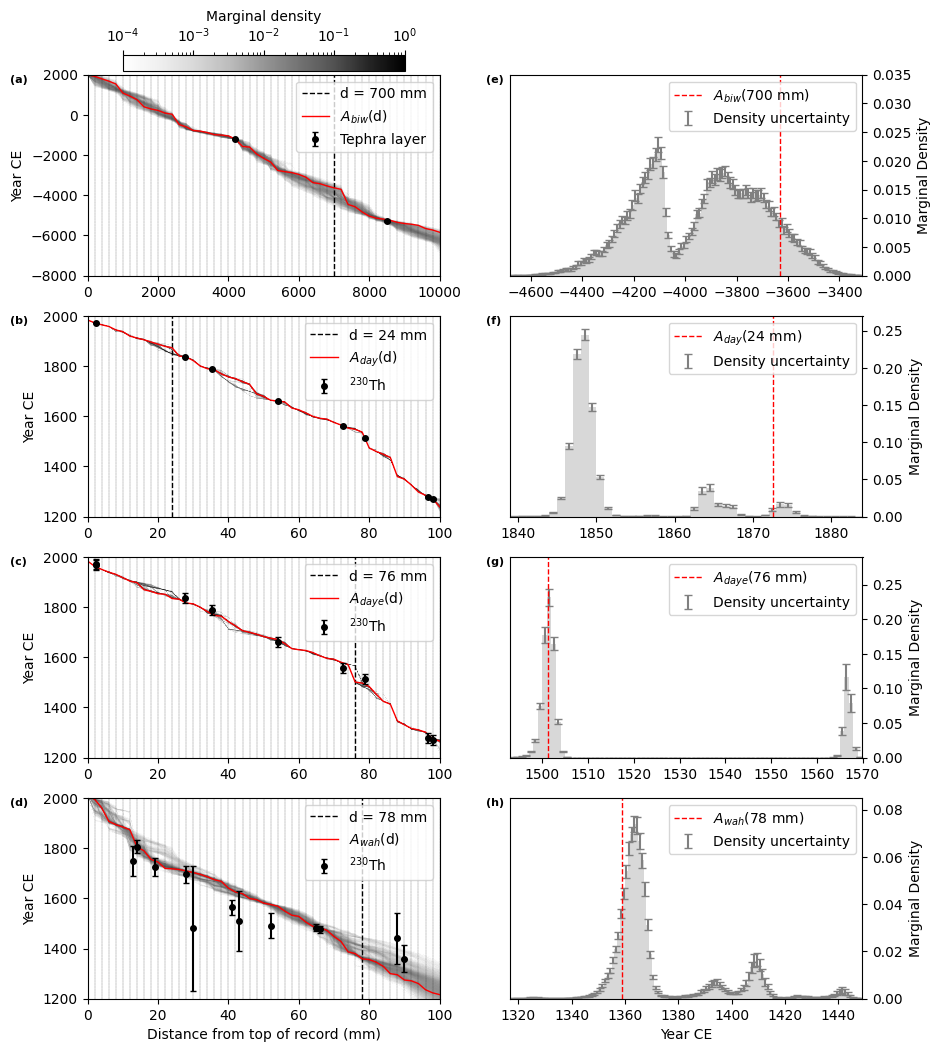

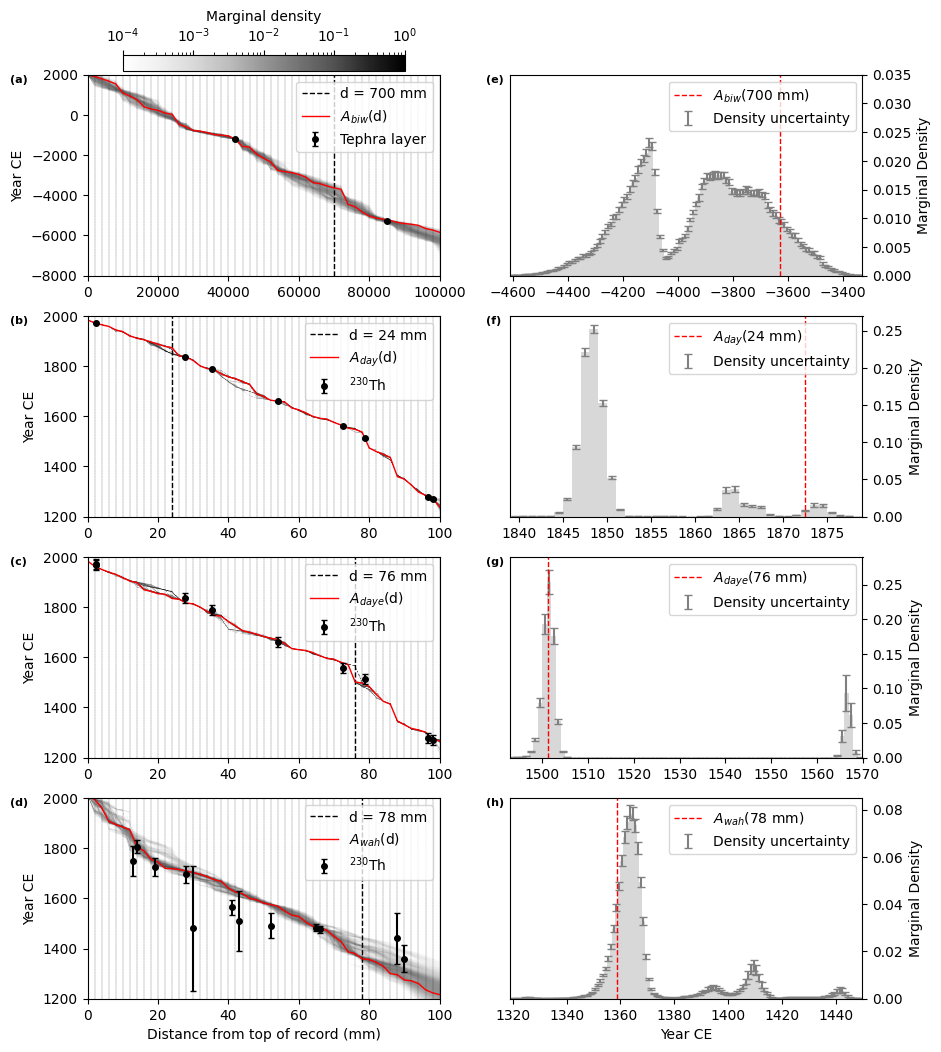

In [ ]:
output_dir = "../../../data"
measure = "Distance from top of record [mm]"
indices = [35, 12, 38, 39]
dts = [10, 1, 1, 1]
dzs = [1, 0.1, 0.1, 0.1]
t_edges_PT = [[-8000, 2000], [1000, 2000], [1000, 2000], [1000, 2010]]
t_edges_OPES = [[-8000, 2000], [1200, 2000], [1200, 2000], [1000, 2010]]
ylims = [[-8000, 2000], [1200, 2000], [1200, 2000], [1200, 2000]]
ylim_marg = [[0, 0.035], [0, 0.27], [0, 0.29], [0, 0.085]]

fig_PT = plt.figure(figsize = (10, 12))
gs_PT = GridSpec(4, 2, figure=fig_PT, width_ratios=[1, 1], hspace=0.2, wspace=0.2)
axL_PT = []
axR_PT = []

fig_OPES = plt.figure(figsize = (10, 12))
gs_OPES = GridSpec(4, 2, figure=fig_OPES, width_ratios=[1, 1], hspace=0.2, wspace=0.2)
axL_OPES = []
axR_OPES = []

for i in range(4):
    true_sample = np.load(f"{output_dir}/{data_names[i]}/{data_versions[i]}/true_sample.npy")
    with open(f"{output_dir}/{data_names[i]}/data.json", "r") as f:
        data = json.load(f)
    true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))

    # Depth interpolation grid
    z = np.arange(0, data["H"] + dzs[i], dzs[i])
    Z = z.size

    # Time interpolation grid
    t_bin_edges_PT = np.arange(t_edges_PT[i][0], t_edges_PT[i][-1] + dts[i], dts[i], dtype = int)
    t_PT = t_bin_edges_PT[1:] - dts[i] / 2
    t_bin_edges_OPES = np.arange(t_edges_OPES[i][0], t_edges_OPES[i][-1] + dts[i], dts[i], dtype = int)
    t_OPES = t_bin_edges_OPES[1:] - dts[i] / 2

    print(f"Plotting PT fig {i}")
    axL_PT.append(fig_PT.add_subplot(gs_PT[i, 0]))
    axR_PT.append(fig_PT.add_subplot(gs_PT[i, 1]))
    plt.set_cmap(plt.cm.Greys)

    if data_names[i] == "biw_dec":
        data["cs"]=10*np.array(data["cs"])
        data["c14d"] = 10*np.array(data["c14d"])
        z*=10
    if data_names[i] == "wah_d18o":
        axL_PT[i].set_xlabel("Distance from top of record (mm)") 
        axR_PT[i].set_xlabel("Year CE") 
    
    axL_PT[i].set_ylabel("Year CE") 
    axR_PT[i].set_ylabel("Marginal density") 
    axL_PT[i].set_ylim(ylims[i])
    axR_PT[i].set_ylim(ylim_marg[i])
    
    interesting_depth = indices[i] * data["dc"]

    # Marginal densities
    im = axL_PT[i].pcolormesh(z, t_PT, PT_Cs[i].T, norm=colors.LogNorm(1e-4, 1))
    for j, c in enumerate(data["cs"]):
        if j ==indices[i]: 
            axL_PT[i].axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} " + measure[-3:-1])
        else:
            axL_PT[i].axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

    # Colorbar for Marginal density, only over first plot
    if data_names[i] == "biw_dec":
        cax = inset_axes(
            axL_PT[i],
            width="80%",
            height="8%",
            loc="upper center",
            bbox_to_anchor=(0, 0.1, 1, 1),
            bbox_transform=axL_PT[i].transAxes,
            borderpad=0
        )

        cbar = fig_PT.colorbar(im, cax=cax, orientation="horizontal")
        cbar.set_label("Marginal density")

        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')

    # True ages
    axL_PT[i].plot(
        data["cs"],
        true_ages,
        color="red",
        alpha=1,
        linewidth=1,
        label = data_labels[i],
    )

    # Vertical discretization lines
    for j, c in enumerate(data["cs"]):
        axL_PT[i].axvline(x=c, color='k', linestyle='--', linewidth = 0.1)
    
    # Direct dates
    axL_PT[i].errorbar(data["c14d"], data["c14"], yerr = data["c14s"], fmt ="o", color = 'k', capsize = 2, markersize=4, label = c14_labels[i])
    axL_PT[i].legend(loc = "upper right")

    # Marginal density
    depth_C = PT_Cs[i][int(interesting_depth/dzs[i]), :]
    depth_sigma = PT_sigma_ests[i][int(interesting_depth/dzs[i]), :]
    sum_jk = depth_C + 2*depth_sigma
    valid_indices = np.where((~np.isnan(sum_jk)) & (sum_jk > 0.0001))[0]
    first_valid_index, last_valid_index = valid_indices[0], valid_indices[-1]

    depth_C = depth_C[first_valid_index:last_valid_index + 1]
    depth_sigma = depth_sigma[first_valid_index:last_valid_index + 1]
    sum_jk = sum_jk[first_valid_index:last_valid_index + 1]
    bin_edges = t_bin_edges_PT[first_valid_index:last_valid_index + 2]

    axR_PT[i].errorbar(t_PT[first_valid_index:last_valid_index + 1], depth_C, yerr=2*depth_sigma, fmt='none', color = "grey", capsize=3, label = r"Density uncertainty")
    axR_PT[i].bar(t_PT[first_valid_index:last_valid_index + 1],  depth_C, width=np.diff(bin_edges), alpha=0.3, color='gray', align='center')
    axR_PT[i].set_xlim(bin_edges[0], bin_edges[-1])
    axR_PT[i].set_ylabel("Marginal Density")
    axR_PT[i].axvline(x=true_ages[indices[i]], color="red", linestyle='--', linewidth = 1, label = data_labels[i][:-3] + f"({int(interesting_depth)} " + measure[-3:-1] + ")")
    axR_PT[i].yaxis.tick_right()
    axR_PT[i].yaxis.set_label_position('right')
    axR_PT[i].legend(loc = "upper right")

    print(f"Plotting OPES fig {i}")
    axL_OPES.append(fig_OPES.add_subplot(gs_OPES[i, 0]))
    axR_OPES.append(fig_OPES.add_subplot(gs_OPES[i, 1]))
    plt.set_cmap(plt.cm.Greys)

    if data_names[i] == "biw_dec":
        data["cs"]=10*np.array(data["cs"])
        data["c14d"] = 10*np.array(data["c14d"])
        z*=10
    if data_names[i] == "wah_d18o":
        axL_OPES[i].set_xlabel("Distance from top of record (mm)") 
        axR_OPES[i].set_xlabel("Year CE") 
    
    axL_OPES[i].set_ylabel("Year CE") 
    axR_OPES[i].set_ylabel("Marginal density") 
    axL_OPES[i].set_ylim(ylims[i])
    axR_OPES[i].set_ylim(ylim_marg[i])
    
    interesting_depth = indices[i] * data["dc"]

    # Marginal densities
    print(np.shape(OPES_Cs[i]))
    print(np.shape(PT_Cs[i]))
    im = axL_OPES[i].pcolormesh(z, t_OPES, OPES_Cs[i].T, norm=colors.LogNorm(1e-4, 1))
    for j, c in enumerate(data["cs"]):
        if j ==indices[i]: 
            axL_OPES[i].axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} " + measure[-3:-1])
        else:
            axL_OPES[i].axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

    # Colorbar for Marginal density, only over first plot
    if data_names[i] == "biw_dec":
        cax = inset_axes(
            axL_OPES[i],
            width="80%",
            height="8%",
            loc="upper center",
            bbox_to_anchor=(0, 0.1, 1, 1),
            bbox_transform=axL_OPES[i].transAxes,
            borderpad=0
        )

        cbar = fig_OPES.colorbar(im, cax=cax, orientation="horizontal")
        cbar.set_label("Marginal density")

        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')

    # True ages
    axL_OPES[i].plot(
        data["cs"],
        true_ages,
        color="red",
        alpha=1,
        linewidth=1,
        label = data_labels[i],
    )

    # Vertical discretization lines
    for j, c in enumerate(data["cs"]):
        axL_OPES[i].axvline(x=c, color='k', linestyle='--', linewidth = 0.1)
    
    # Direct dates
    axL_OPES[i].errorbar(data["c14d"], data["c14"], yerr = data["c14s"], fmt ="o", color = 'k', capsize = 2, markersize=4, label = c14_labels[i])
    axL_OPES[i].legend(loc = "upper right")

    # Marginal density
    depth_C = OPES_Cs[i][int(interesting_depth/dzs[i]), :]
    depth_sigma = OPES_sigma_ests[i][int(interesting_depth/dzs[i]), :]
    sum_jk = depth_C + 2*depth_sigma
    valid_indices = np.where((~np.isnan(sum_jk)) & (sum_jk > 0.0001))[0]
    first_valid_index, last_valid_index = valid_indices[0], valid_indices[-1]

    depth_C = depth_C[first_valid_index:last_valid_index + 1]
    depth_sigma = depth_sigma[first_valid_index:last_valid_index + 1]
    sum_jk = sum_jk[first_valid_index:last_valid_index + 1]
    bin_edges = t_bin_edges_OPES[first_valid_index:last_valid_index + 2]

    axR_OPES[i].errorbar(t_OPES[first_valid_index:last_valid_index + 1], depth_C, yerr=2*depth_sigma, fmt='none', color = "grey", capsize=3, label = r"Density uncertainty")
    axR_OPES[i].bar(t_OPES[first_valid_index:last_valid_index + 1],  depth_C, width=np.diff(bin_edges), alpha=0.3, color='gray', align='center')
    axR_OPES[i].set_xlim(bin_edges[0], bin_edges[-1])
    axR_OPES[i].set_ylabel("Marginal Density")
    axR_OPES[i].axvline(x=true_ages[indices[i]], color="red", linestyle='--', linewidth = 1, label = data_labels[i][:-3] + f"({int(interesting_depth)} " + measure[-3:-1] + ")")
    axR_OPES[i].yaxis.tick_right()
    axR_OPES[i].yaxis.set_label_position('right')
    axR_OPES[i].legend(loc = "upper right")


letters = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)"]

for i, ax in enumerate(axL_PT):
    ax.text(
        -0.22, 1.00,
        letters[i],
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
        va="top",
        ha="left"
    )

for i, ax in enumerate(axR_PT):
    ax.text(
        -0.07, 1.00,
        letters[i + len(axR_PT)],
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
        va="top",
        ha="left"
    )

for i, ax in enumerate(axL_OPES):
    ax.text(
        -0.22, 1.00,
        letters[i],
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
        va="top",
        ha="left"
    )

for i, ax in enumerate(axR_OPES):
    ax.text(
        -0.07, 1.00,
        letters[i + len(axR_OPES)],
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
        va="top",
        ha="left"
    )

fig_PT.tight_layout()
fig_PT.savefig("age_depth_PT.png", dpi=300, bbox_inches="tight")

fig_OPES.tight_layout()
fig_OPES.savefig("age_depth_OPES.png", dpi=300, bbox_inches="tight")
plt.show()


In [72]:
min_energy_samples = PT_samples_partial_dayu[-1, np.argmin(PT_energy_partial_dayu[-1, :])]
with open(f"{output_dir}/dayu_d18o/data.json", "r") as f:
    data = json.load(f)
true_sample = np.load(f"{output_dir}/dayu_d18o/2/true_sample.npy")
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))


In [71]:
data_file = pd.read_csv(
    f"{output_dir}/dayu_d18o/2/data.txt", sep="\t"
)
d18o = data_file["ref"].to_numpy()
d18o_depths = data_file["depth"].to_numpy()
d18o_sigma = data_file["sigma_ref"].to_numpy()
d18o_true_ages = data_file["true_age"].to_numpy()

mask = ~np.isnan(d18o)
d18o = d18o[mask]
d18o_depths = d18o_depths[mask]
d18o_sigma = d18o_sigma[mask]
d18o_true_ages = d18o_true_ages[mask]

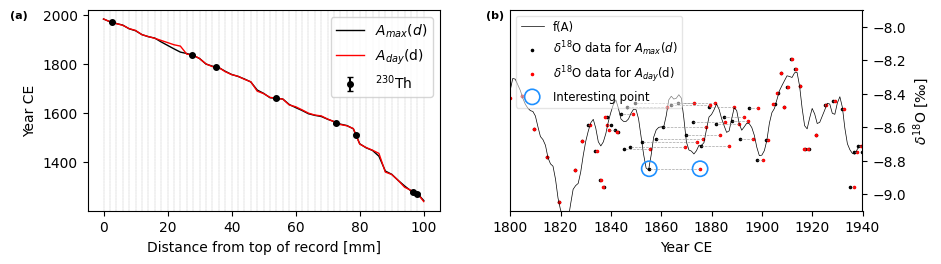

In [87]:
fig_fit = plt.figure(figsize = (10, 12))
gs_fit = GridSpec(4, 2, figure=fig_fit, width_ratios=[1, 1], hspace=0.2, wspace=0.2)
axL_fit = []
axR_fit = []

axL_fit.append(fig_fit.add_subplot(gs_fit[0, 0]))
axR_fit.append(fig_fit.add_subplot(gs_fit[0, 1]))
axL_fit[0].plot(data["cs"], data["th"] - data["dc"]*np.hstack(([0], np.cumsum(min_energy_samples))), color = "black", alpha = 1, linewidth = 1, label = r"$A_{max}(d)$")
axL_fit[0].plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_labels[1])
for i, c in enumerate(data["cs"]):
    axL_fit[0].axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

axL_fit[0].errorbar(data["c14d"], data["c14"], yerr = data["c14s"], fmt ="o", color = 'k', capsize = 2, markersize=4, label = c14_labels[1])
axL_fit[0].set_xlabel(measure)
axL_fit[0].set_ylabel("Year CE")
axL_fit[0].legend()

axR_fit[0].plot(data["d18ort"], data["d18or"], color = "black", linewidth = 0.5, label = "f(A)")

axR_fit[0].scatter(
    np.interp(d18o_depths, data["cs"], data["th"] - data["dc"]*np.hstack(([0], np.cumsum(min_energy_samples)))), 
    d18o, 
    color="black", 
    marker=".", 
    s=10,
    label=r"$\delta^{18}$O data for $A_{max}(d)$",
)

axR_fit[0].scatter(
    d18o_true_ages, 
    d18o, 
    color="red", 
    marker = ".", 
    s = 10,
    label=r"$\delta^{18}$O data for " + data_labels[1]
)

interp_ages = np.interp(
    d18o_depths,
    data["cs"],
    data["th"] - data["dc"] * np.hstack(([0], np.cumsum(min_energy_samples)))
)

for xi1, xi2, yi in zip(d18o_true_ages, interp_ages, d18o):
    axR_fit[0].plot(
        [xi1, xi2],
        [yi, yi],
        color="gray",
        linestyle="--",
        linewidth=0.5,
        alpha=0.7
    )

mask = (
    (d18o_true_ages >= 1850) & (d18o_true_ages <= 1880) &
    (d18o  <= -8.8)
)

axR_fit[0].scatter(
    d18o_true_ages[mask],
    d18o[mask],
    facecolors='none',
    edgecolors='dodgerblue',
    s=120,
    linewidths=1.2,
    zorder=6
)

axR_fit[0].scatter(
    interp_ages[mask],
    d18o[mask],
    facecolors='none',
    edgecolors='dodgerblue',
    s=120,
    linewidths=1.2,
    zorder=6, 
    label = "Interesting point"
)

letters = ["(a)", "(b)"]

for i, ax in enumerate(axL_fit):
    ax.text(
        -0.22, 1.00,
        letters[i],
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
        va="top",
        ha="left"
    )

for i, ax in enumerate(axR_fit):
    ax.text(
        -0.07, 1.00,
        letters[i + len(axR_fit)],
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
        va="top",
        ha="left"
    )

axR_fit[0].set_xlim((1800, 1940))
axR_fit[0].set_ylabel("$\\delta^{18}$O [‰]")
axR_fit[0].set_xlabel("Year CE")
axR_fit[0].legend(framealpha=0.5, loc = "upper left", fontsize="small")
axR_fit[0].set_ylim(-9.1, -7.9)
axR_fit[0].yaxis.tick_right()
axR_fit[0].yaxis.set_label_position('right')
# axR_fit[0].tight_layout()
plt.savefig(f"data_fit_dayu.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
PT_partial_energies = [
    PT_energy_partial_biw[-1][cutout:],
    PT_energy_partial_dayu[-1][cutout:],
    PT_energy_partial_dayu_edit[-1][cutout:],
    PT_energy_partial_wah[-1][cutout:],
]

PT_full_energies = [
    PT_energy_full_biw[-1][cutout:],
    PT_energy_full_dayu[-1][cutout:],
    PT_energy_full_dayu_edit[-1][cutout:],
    PT_energy_full_wah[-1][cutout:],
]

OPES_partial_energies = [
    OPES_energy_partial_biw[:, cutout:].flatten(order = 'F'),
    OPES_energy_partial_dayu[:, cutout:].flatten(order = 'F'),
    OPES_energy_partial_dayu_edit[:, cutout:].flatten(order = 'F'),
    OPES_energy_partial_wah[:, cutout:].flatten(order = 'F'),
]

OPES_full_energies = [
    OPES_energy_full_biw[:, cutout:].flatten(order = 'F'),
    OPES_energy_full_dayu[:, cutout:].flatten(order = 'F'),
    OPES_energy_full_dayu_edit[:, cutout:].flatten(order = 'F'),
    OPES_energy_full_wah[:, cutout:].flatten(order = 'F'),
]

HMC_energies =[
    HMC_energy_biw[:3, cutout:].flatten(),
    HMC_energy_dayu[:, cutout:].flatten(),
    HMC_energy_dayu_edit[:, cutout:].flatten(),
    HMC_energy_wah[:, cutout:].flatten(),
]




In [ ]:
OPES_weights_partial_biw = np.exp(OPES_bias_partial_biw[:, cutout:].flatten(order = 'F'))
OPES_weights_partial_dayu = np.exp(OPES_bias_partial_dayu[:, cutout:].flatten(order = 'F'))
OPES_weights_partial_dayu_edit = np.exp(OPES_bias_partial_dayu_edit[:, cutout:].flatten(order = 'F'))
OPES_weights_partial_wah = np.exp(OPES_bias_partial_wah[:, cutout:].flatten(order = 'F'))

OPES_weights_partial_biw /= np.sum(OPES_weights_partial_biw)
OPES_weights_partial_dayu /= np.sum(OPES_weights_partial_dayu)
OPES_weights_partial_dayu_edit /= np.sum(OPES_weights_partial_dayu_edit)
OPES_weights_partial_wah /= np.sum(OPES_weights_partial_wah)

OPES_weights_full_biw = np.exp(OPES_bias_full_biw[:, cutout:].flatten(order = 'F'))
OPES_weights_full_dayu = np.exp(OPES_bias_full_dayu[:, cutout:].flatten(order = 'F'))
OPES_weights_full_dayu_edit = np.exp(OPES_bias_full_dayu_edit[:, cutout:].flatten(order = 'F'))
OPES_weights_full_wah = np.exp(OPES_bias_full_wah[:, cutout:].flatten(order = 'F'))

OPES_weights_full /= np.sum(OPES_weights_full)
OPES_weights_full /= np.sum(OPES_weights_full)
OPES_weights_full /= np.sum(OPES_weights_full)
OPES_weights_full /= np.sum(OPES_weights_full)

NameError: name 'OPES_weights_full' is not defined

In [271]:
bs = np.geomspace(1.0, 1.0 / 20, 20)[::-1]


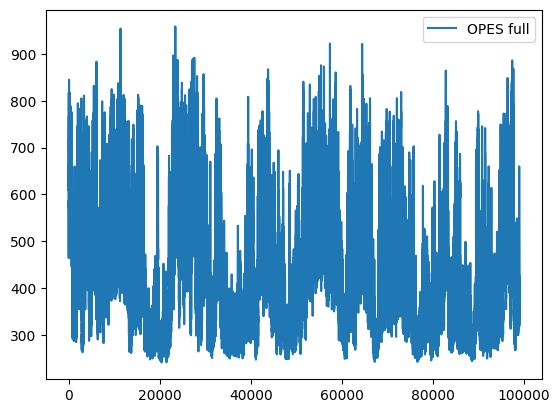

In [272]:
# Find reasonable cutout
plt.figure()
# plt.plot(PT_energy_partial[-1, cutout:], label = "PT partial")
# plt.plot(PT_energy_full[-1, cutout:], label = "PT full")
# plt.plot(energies[2] + OPES_bias_partial[:, cutout:].flatten(order = 'F'), label = "OPES partial")
plt.plot(OPES_energy_full[0, 1000:], label = "OPES full")
# plt.plot(HMC_energy[:, cutout:].flatten(order = 'F'), label = "HMC")
plt.legend()
# plt.ylim([350, 450])
plt.show()

In [273]:
def weighted_quantile(values, quantiles, sample_weight=None):
    values = np.asarray(values)
    quantiles = np.asarray(quantiles)

    if sample_weight is None:
        sample_weight = np.ones(len(values))

    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]

    cdf = np.cumsum(sample_weight)
    cdf /= cdf[-1]

    return np.interp(quantiles, cdf, values)

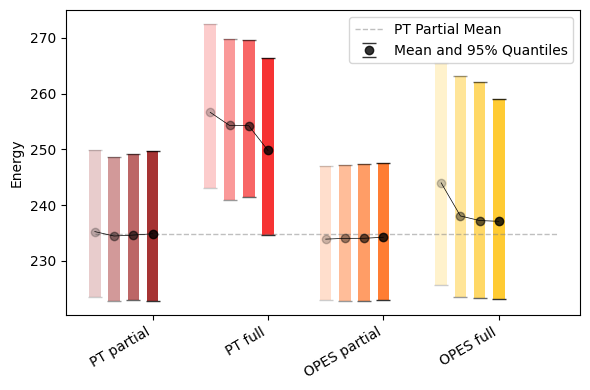

In [276]:
# Biwa
cutout_PT_partial = 10000
cutout_PT_full = 10000
cutout_OPES_partial = 10000
cutout_OPES_full = 10000
cutout_HMC = 10000

# # Dayu
# cutout_PT_partial = 100
# cutout_PT_full = 100
# cutout_OPES_partial = 100
# cutout_OPES_full = 100
# cutout_HMC = 50000
# HMC_chain = 0

# # Dayu edit
# cutout_PT_partial = 5000
# cutout_PT_full = 10000
# cutout_OPES_partial = 100
# cutout_OPES_full = 10000
# cutout_HMC = 10000
# HMC_chain = 3

## Wah
# cutout_PT_partial = 15000
# cutout_PT_full = 60000
# cutout_OPES_partial = 100
# cutout_OPES_full = 50000

energies = [
    PT_energy_partial[-1][cutout_PT_partial:],
    PT_energy_full[-1][cutout_PT_full:],
    OPES_energy_partial[:, cutout_OPES_partial:].flatten(order = "F"),
    OPES_energy_full[:, cutout_OPES_full:].flatten(order = "F"),
    # HMC_energy[0, cutout_HMC:],
]

OPES_weights_partial = np.exp(OPES_bias_partial[:, cutout_OPES_partial:]).flatten(order = "F")
OPES_weights_partial /= np.sum(OPES_weights_partial)
OPES_weights_full = np.exp(OPES_bias_full[:, cutout_OPES_full:]).flatten(order = "F")
OPES_weights_full /= np.sum(OPES_weights_full)

PT_partial_weights = np.ones((len(energies[0])))
PT_full_weights = np.ones((len(energies[1])))
HMC_weights = np.ones((len(energies[-1])))


weights = [
    PT_partial_weights,
    PT_full_weights,
    OPES_weights_partial,
    OPES_weights_full,
    HMC_weights,
]

# Optional: labels for the runs
labels = [
    "PT partial",
    "PT full",
    "OPES partial",
    "OPES full",
    # "HMC",
]

# Compute means and standard deviations
fractions = [0, 0.1, 0.25, 0.5, 1.0]
means = np.full((len(energies), len(fractions)-1), np.nan)
stds = np.full((len(energies), len(fractions)-1), np.nan)

for i, e in enumerate(energies):
    for j, f in enumerate(fractions[:-1]):
        n = int(fractions[j+1] * len(e))
        pre_n = int(f * len(e))
        means[i, j] = np.average(e[pre_n:n], weights = weights[i][pre_n:n])
        stds[i, j] = np.sqrt(np.average((e[pre_n:n] - means[i, j])**2, weights = weights[i][pre_n:n]))
    
fig, ax = plt.subplots(figsize=(6, 4))
cmap = plt.get_cmap("hot")
colors = [cmap(x) for x in np.linspace(0.2, 0.8, 5)]
alphas = np.linspace(0.2, 0.8, 4)

x = np.arange(len(energies))
ax.hlines(means[0, -1], -0.5, len(energies)-0.5,
          color="gray", linestyle="--", linewidth=1, alpha=0.5, label = "PT partial mean ")

for i in range(len(energies)):
    ax.plot(x[i] - 0.5 + (1/6)*np.arange(len(fractions)-1), means[i], "-", color = "black", linewidth = 0.5)
    for j in range(len(fractions)-1):
        mu = means[i, j]
        s = stds[i, j]
        label = r"Mean and 95% quantiles" if (i == 0 and j == len(fractions)-2) else ""

        # recompute slice
        pre_n = int(fractions[j] * len(energies[i]))
        n = int(fractions[j+1] * len(energies[i]))
        # mean marker (emphasized)
        # ax.scatter(x[i] - 0.5 + (1/8)*j, mu, color="black", s=60, zorder=3)

        # x-position of this subgroup
        x0 = x[i] - 0.5 + (1/6)*j

        # data slice
        data = energies[i][pre_n:n]
        w = weights[i][pre_n:n]

        # central 95% interval
        q_low, q_high = weighted_quantile(
            data,
            [0.025, 0.975],
            sample_weight=w
        )

        ax.fill_between(
            [x0 - 0.05, x0 + 0.05],
            q_low,
            q_high,
            color=colors[i],
            alpha=alphas[j],
            linewidth=0
        )

        ax.errorbar(
            x0,
            mu,
            yerr=[[mu - q_low], [q_high - mu]],
            fmt='o',
            capsize=5,
            linewidth=0,
            color = "black",
            label = label,
            alpha = alphas[j],
        )
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')

ax.set_ylabel("Energy")

# plt.ylim((350,700))
plt.legend(loc = "upper right")
plt.tight_layout()
plt.savefig(f"new_conpare_{data_name}.jpg")
plt.show()
